# Classifying CIFAR10 images using a ResNet and Regularization techniques in PyTorch
### AKA Train an image classifier from scratch to over 90% accuracy in less than 10 minutes

This notebook is an extension to the tutorial [**Image Classification using CNNs in PyTorch**](https://jovian.ml/aakashns/05-cifar10-cnn), where we trained a deep convolutional neural network to classify images from the CIFAR10 dataset with around 55% accuracy. In this tutorial, we'll use the following techniques to achieve over 90% accuracy in less than 10 minutes:
* Data normalization
* Data augmentation
* Residual connections
* Batch normalization
* Learning rate annealing
* Weight Decay
* Gradient clipping

## Preparing the Data
Let's begin by downloading the dataset and creating PyTorch datasets to load the data, just as we did in the previous tutorial.

In [1]:
import os
import torch
import torchvision
import tarfile
from torchvision.datasets.utils import download_url

In [2]:
import os, tarfile
from torchvision.datasets.utils import download_url

dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(dataset_url, '.')

with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path='./data')

data_dir = './data/cifar10'

print(os.listdir(data_dir))
classes = os.listdir(os.path.join(data_dir, "train"))
print(classes)


/tmp/ipykernel_30860/2263303700.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='./data')


['train', 'test']
['cat', 'deer', 'automobile', 'horse', 'dog', 'ship', 'frog', 'airplane', 'truck', 'bird']


There are a few of important changes we'll make while creating the PyTorch datasets:

1. Instead of setting aside a fraction (e.g. 10%) of the data from the training set for validation, we'll simply use the test set as our validation set. This just gives a little more data to train with.

2. We will normalize the image tensors by subtracting the mean and dividing by the standard deviation across each channel. As a result, the mean of the data across each channel is 0, and standard deviation is 1. Normalizing the data prevents the values from any one channel from disproportionately affecting the losses and gradients while training, simply by having a higher or wider range of values that others.

3. We will apply randomly chosen transformations while loading images from the training dataset. Specifically, we will pad each image by 4 pixels, and then take a random crop of size 32 x 32 pixels, and then flip the image horizontally with a 50% probability. Since the transformation will be applied randomly and dynamically each time a particular image is loaded, the model sees slightly different images in each epoch of training, which allows it generalize better.

<img src="https://imgaug.readthedocs.io/en/latest/_images/cropandpad_percent.jpg">

In [3]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt

In [4]:
# Data transforms (normalization & data augmentation)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
#These are normalization numbers:
# First 3 numbers → average color values (Red, Green, Blue)
# Next 3 numbers → how much the colors usually change
# In simple words:
# These numbers help make all images have similar color ranges, so the AI learns better.
# Think:
# 👉 “Make all photos balanced in brightness and color.”
train_tfms = tt.Compose([
    tt.RandomCrop(32, padding=4),
    tt.RandomHorizontalFlip(),
    tt.ToTensor(),
    tt.Normalize(*stats)
])
#👉 This is called data augmentation = making fake variations of images to help the AI learn better.
valid_tfms = tt.Compose([tt.ToTensor(), tt.Normalize(*stats)])
# This is simpler:
# No random crop
# No flipping
# Only:
# turn image into numbers
# normalize colors
# Why?
# 👉 Because validation images must be clean and unchanged so evaluation is fair.
# training images:
# Crop randomly → flip sometimes → turn into numbers → fix colors
# (so the model learns better)
# Validation images:
# Turn into numbers → fix colors
# (so testing is fair)

In [5]:
# PyTorch datasets
train_ds = ImageFolder(data_dir+'/train', train_tfms)
valid_ds = ImageFolder(data_dir+'/test', valid_tfms)

Next, we can create data loaders for retrieving images in batches.

In [6]:
from torch.utils.data import DataLoader

In [7]:
batch_size = 256

In [8]:
# PyTorch data loaders
train_dl = DataLoader(train_ds, batch_size, shuffle=True,
                      num_workers=8, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size, shuffle=False,
                      num_workers=8, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


The `num_workers` argument can be used to leverage multiple CPU cores and load images in parallel. The `pin_memory` argument avoid repeated memory allocation and deallocation by using the same portion of memory (RAM) for loading each batch of data. We are able to do this because all images have the same size (32px x 32px). These small changes in our pipeline lead to significant performance gains.

Before we proceed, let's take a look at one batch of data.

In [9]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [10]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(16, 16))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images[:100], 10).permute(1, 2, 0))
        break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


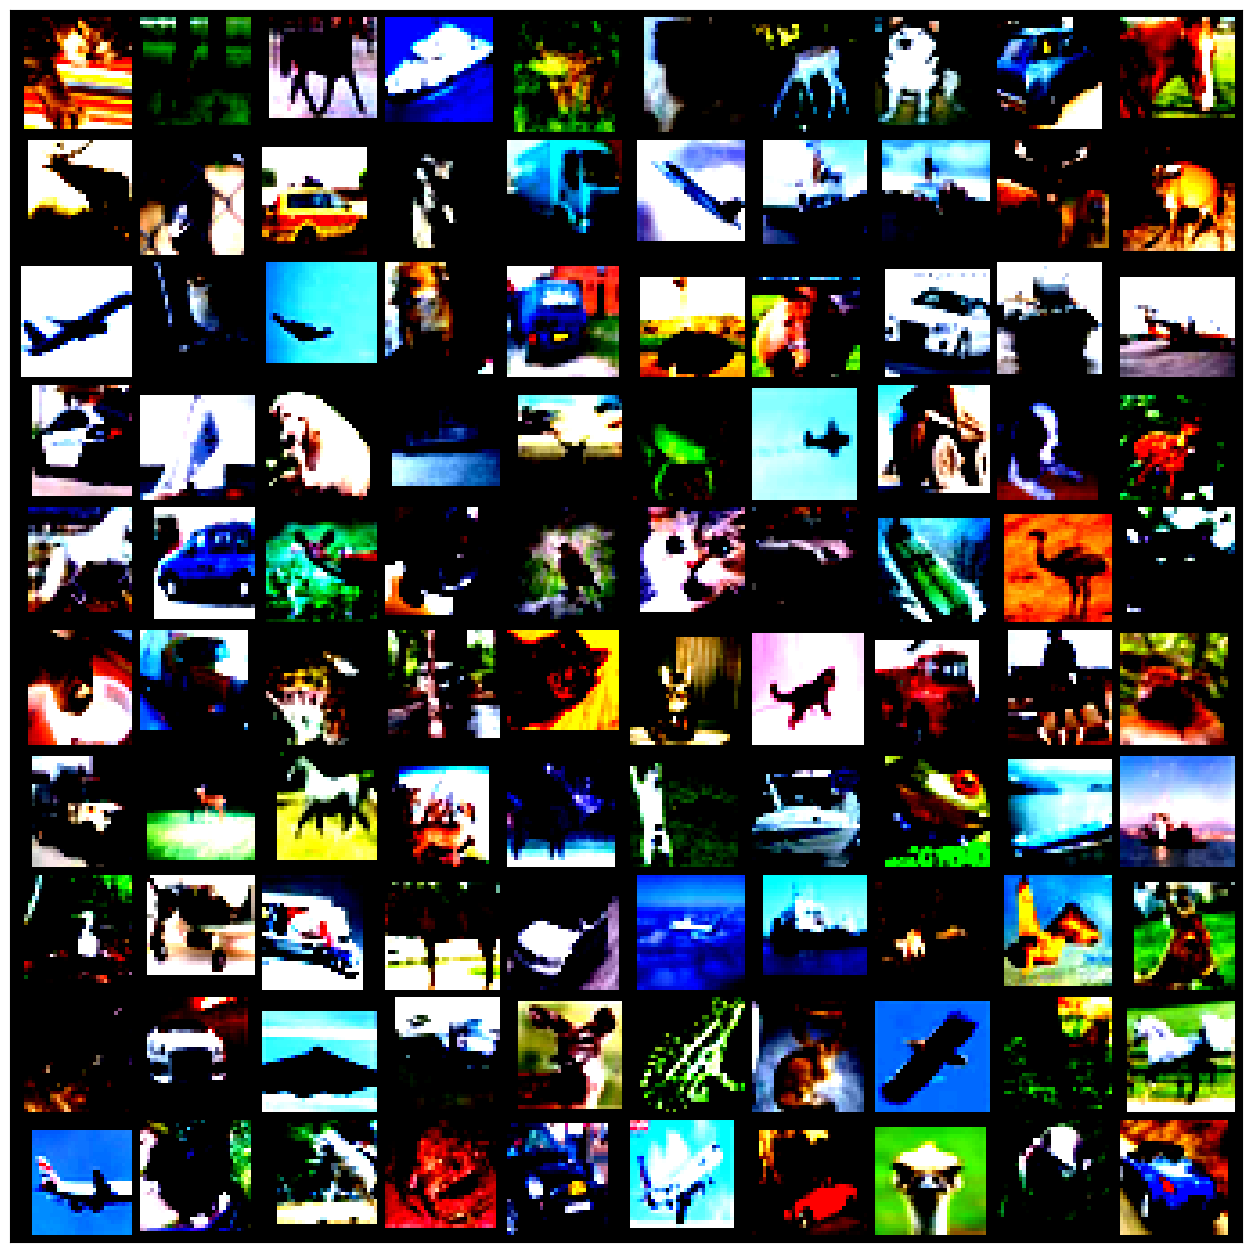

In [11]:
show_batch(train_dl)

The colors seem out of place because of the normalization. Note that normalization is also applied during inference. If you look closely, you can see the cropping and reflection padding in some of the images. Horizontal flip is a bit difficult to detect from visual inspection.

## Model with Residual Blocks and Batch Normalization

We'll use a significatly larger model this time, called the WideResNet22, which has 22 convolutional layers. However, one of the key changes to our model is the addition of the **resudial block**, which adds the original input back to the output feature map obtained by passing the input through one or more convolutional layers.

<img src="https://miro.medium.com/max/1140/1*D0F3UitQ2l5Q0Ak-tjEdJg.png">

Here is a very simply Residual block:

In [12]:
import torch.nn as nn
import torch.nn.functional as F

In [13]:
class SimpleResidualBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        # Both conv layers keep the same number of channels (3 → 3).
        # Kernel size 3 and padding 1 ensures the spatial dimensions(height and width) stay the same.
        # ReLU after each convolution for non-linearity.
    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        return self.relu2(out + x)
        # The residual connection out + x adds the input x to the output of the second convolution.
        # This is exactly how ResNet blocks work—it helps gradients flow better and reduces vanishing gradient problems.

In [14]:
simple_resnet = SimpleResidualBlock()

for images, labels in train_dl:
    out = simple_resnet(images)
    print(out.shape)
    break

torch.Size([256, 3, 32, 32])


This seeming small change produces a drastic improvement in the performance of the model. Here's a great blog post explaining why and how residual blocks work: https://towardsdatascience.com/residual-blocks-building-blocks-of-resnet-fd90ca15d6ec .

Also, after each convolutional layer, we'll add a batch normalization layer. Here's a good explanation of batch normalization: https://towardsdatascience.com/batch-normalization-and-dropout-in-neural-networks-explained-with-pytorch-47d7a8459bcd


We'll define a series of helper functions to create the WideResNet22 network, which has the following structure:

<img src="https://miro.medium.com/max/2500/1*gOyiFYGHMAEDlyoAIhkWkA.png">


In [15]:
def conv_2d(ni, nf, stride=1, ks=3):
    return nn.Conv2d(in_channels=ni, out_channels=nf,
                     kernel_size=ks, stride=stride,
                     padding=ks//2, bias=False)
# What it does:
# Creates a convolution layer with:
# ni → input channels
# nf → output channels
# ks → kernel size (default 3)
# padding = ks//2 → keeps spatial size same for odd kernels
# bias=False → because BatchNorm handles bias
# So this is a standard ResNet-style conv layer.
def bn_relu_conv(ni, nf):
    return nn.Sequential(nn.BatchNorm2d(ni),
                         nn.ReLU(inplace=True),
                         conv_2d(ni, nf))

# This is a block:
# BatchNorm → ReLU → Conv
# This is called pre-activation ordering, used in modern ResNets:
# BN first
# then ReLU
# then Conv
# This improves gradient flow and training stability.
class ResidualBlock(nn.Module):
    def __init__(self, ni, nf, stride=1):
    # ni = number of input channels
    # nf = number of output channels
    # stride = controls downsampling (spatial size reduction)
        super().__init__()
        self.bn = nn.BatchNorm2d(ni)
        self.conv1 = conv_2d(ni, nf, stride)
        self.conv2 = bn_relu_conv(nf, nf)
        # So the main path is:
        # BN + ReLU (in forward)
        # Conv1: ni → nf, may downsample
        # BN + ReLU + Conv2: nf → nf

        # This is very important:
        # Case 1: ni == nf
        self.shortcut = lambda x: x
        # → Identity shortcut
        # → x is added directly (no change)

        # Case 2: ni != nf
        if ni != nf:
            self.shortcut = conv_2d(ni, nf, stride, 1)
        # → Uses a 1×1 convolution to:
        # match channels (ni → nf)
        # match spatial size (via stride)
        # This is exactly how real ResNet handles dimension mismatch.

    def forward(self, x):
        # Step-by-step:
        # 1) Pre-activation
        x = F.relu(self.bn(x), inplace=True)
        # BN → ReLU before any convolution
        # 👉 This is Pre-Activation ResNet design

        # 2) Shortcut path
        r = self.shortcut(x)
        # This is the residual (skip) branch:
        # either identity
        # or 1×1 conv projection

        # 3) Main path
        x = self.conv1(x)
        x = self.conv2(x) * 0.2
        # Two conv layers, but notice:
        # * 0.2
        # 🔥 Residual scaling
        # This is residual scaling:
        # Reduces magnitude of residual
        # Stabilizes training
        # Common in deep networks and super-resolution models
        # So instead of:
        # output = residual + shortcut
        # You get:
        # output = 0.2 * residual + shortcut
        # This prevents exploding activations.

        # 4) Residual addition
        return x.add_(r)
        # This is:
        # output = x + r
        # But add_ is in-place addition (memory efficient).



In [16]:
def make_group(N, ni, nf, stride):
    start = ResidualBlock(ni, nf, stride)
    rest = [ResidualBlock(nf, nf) for j in range(1, N)]
    return [start] + rest
# This builds one ResNet stage (group).
# Meaning:
# N = number of residual blocks in this group
# ni = input channels
# nf = output channels
# stride = spatial downsampling factor
# Structure:
# First block
# changes channels (ni → nf)
# may downsample (stride=2)
# Remaining blocks:
# nf → nf
# no downsampling
# So each group looks like:
# [ ResidualBlock(ni → nf, stride) ,
#   ResidualBlock(nf → nf) ,
#   ResidualBlock(nf → nf) , ... ]
# This is exactly how ResNet stages are built.
class Flatten(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, x): return x.view(x.size(0), -1)
# Converts:
# (batch, channels, height, width)→
# (batch, features)
# So it prepares data for the final Linear classifier.

# WideResNet class
class WideResNet(nn.Module):
# This is the full model.
    def __init__(self, n_groups, N, n_classes, k=1, n_start=16):
        super().__init__()
        # Increase channels to n_start using conv layer
        # Step 1: Input projection
        layers = [conv_2d(3, n_start)]
        n_channels = [n_start]
        # Input:
        # RGB image (3 channels)
        # → conv → n_start channels (default = 16)
        # This is the stem layer.

        # Add groups of BasicBlock(increase channels & downsample)
        # Step 2: Residual groups
        for i in range(n_groups):
            n_channels.append(n_start*(2**i)*k)
            stride = 2 if i>0 else 1
            layers += make_group(N, n_channels[i],
                                 n_channels[i+1], stride)
# Channel growth formula:
# n_start * (2**i) * k
# This means:
# channels double each group
# multiplied by width factor k (Wide ResNet idea)
# So with n_start=16, k=6:
# Group	Channels
# 0	    16 × 1 × 6 = 96
# 1	    16 × 2 × 6 = 192
# 2	    16 × 4 × 6 = 384
# Stride logic:
# stride = 2 if i>0 else 1
# So:
# Group 0 → no downsampling
# Group 1 → spatial downsample
# Group 2 → spatial downsample
# This matches ResNet design:
# 32×32 → 32×32 → 16×16 → 8×8
        # Pool, flatten & add linear layer for classification
        # Final layers (classifier head)
        layers += [nn.BatchNorm2d(n_channels[3]),
                   nn.ReLU(inplace=True),
                   nn.AdaptiveAvgPool2d(1),
                   Flatten(),
                   nn.Linear(n_channels[3], n_classes)]
# Meaning:
# BN + ReLU → normalize features
# AdaptiveAvgPool2d(1) → global average pooling
# (C, H, W) → (C, 1, 1)
# Flatten() → (C, 1, 1) → (C)
# Linear(C → n_classes) → classification logits
# This is modern CNN classifier design (no huge FC
        # Forward
        self.features = nn.Sequential(*layers)

    def forward(self, x): return self.features(x)
    # Everything is one sequential pipeline.
# Model factory
def wrn_22():
    return WideResNet(n_groups=3, N=3, n_classes=10, k=8)
# This defines a WRN-22-6:
# Why WRN-22-6?
# Depth formula:
# depth = 1 + n_groups * N * 2 + 1
#       = 1 + 3*3*2 + 1
#       = 22 layers
# Width factor k = 6
# So this is:
# WideResNet-22-6

In [17]:
model = wrn_22()

In [18]:
for images, labels in train_dl:
    print('images.shape:', images.shape)
    out = model(images)
    print('out.shape:', out.shape)
    break

images.shape: torch.Size([256, 3, 32, 32])
out.shape: torch.Size([256, 10])


## Training the model

In the previous tutorials, we defined helper functions to train the model. This time, we'll use some functions from the FastAI library, which builds on top of PyTorch and offers many utilities, including a powerful & customizable training loop with learning rate scheduling.

Learning rate scheduling refers to the process of dynamically changing the learning rate while the model is being trained. There are many strategies for changing the learning rate during training, and the one we'll use is called the 1-cycle policy. We start out with a low learning rate, then gradually increase it linearly to high value for about half of the training, and then slowly bring it to the original value. At the end, we train for few iterations with a very low learning rate.

<img src="https://sgugger.github.io/images/art5_lr_schedule.png">

Here's a great explanation of the 1-cycle policy: https://sgugger.github.io/the-1cycle-policy.html


In [19]:
from fastai.tabular.all import *
from fastai.text.all import *
from fastai.vision.all import *

First, we create a `DataBunch` object to using the data loaders we created previously, and then we create a `Learner` object using the data bunch, model and a loss function.

In [20]:
dls = DataLoaders(train_dl, valid_dl)

# Create Learner
learn = Learner(
    dls,
    model,
    loss_func=F.cross_entropy,
    metrics=accuracy,
    cbs=GradientClip(0.5)
)

The statement `GradientClip(0.1)` is used to perform gradient clipping i.e. it limits the values of gradients to the range `[-1,1]`, thus preventing the undesirable changes in the parameters (weights & biases) due to large gradient values.

FastAI also provides a helpful learning rate finder, which tries a range of learning rates, and helps you select a good learning rate by looking at the graph of loss vs. learning rate.

🔎 What lr_find() Does (Simple)

It:

Starts with a very small learning rate

Slowly increases it

Measures the loss

Plots a graph

Then FastAI suggests a good learning rate.

Based on the above graph, it seems like a learning rate of `5e-3` leads to the fastest reduction in loss.

To train the model using the 1-cycle policy, we use the `.fit_one_cycle` method, and pass in the no. of epochs and the maximum learning rate. We also use [weight decay](https://towardsdatascience.com/this-thing-called-weight-decay-a7cd4bcfccab), which is yet another regularization technique which prevents the weights from becoming too large by adding an additional term to the loss function.

In [21]:
learn.fit(10, 5e-3, wd = 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,1.376778,1.598720,0.479900,02:10
1,0.998124,1.085751,0.640400,02:09
2,0.787553,0.895227,0.690600,02:09
3,0.633913,0.718355,0.752500,02:08
4,0.541231,0.591545,0.803600,02:08
5,0.470387,0.553848,0.817900,02:08
6,0.403959,0.693288,0.784700,02:09
7,0.373154,0.512720,0.838600,02:09
8,0.323402,0.468661,0.850000,02:09
9,0.293627,0.584987,0.829200,02:08


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [22]:
learn.fit_one_cycle(10, 5e-3, wd = 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.183900,0.337639,0.887000,02:08
1,0.227469,0.511889,0.850900,02:08
2,0.236675,0.456281,0.860900,02:08
3,0.212142,0.399912,0.876000,02:08
4,0.168272,0.378508,0.890500,02:08
5,0.136099,0.324280,0.906700,02:08
6,0.093272,0.312720,0.914300,02:09
7,0.061407,0.309908,0.920700,02:09
8,0.041619,0.313673,0.922300,02:09
9,0.036542,0.312034,0.924200,02:09


As you can see, the model quickly reaches an accuracy of over 90% in just 9 epochs. It is quite a feat, considering that our simple CNN model struggled to reach 60% accuracy even after training for a long time.

In fact, if we continue to train this model for longer, it will soon reach an accuracy of around 95%, which is quite close to the state of the art. The model and techniques covered in this tutorial were actually used by the FastAI team for their submission to the Stanform DawnBench competition.

Let's plot the learning rates, losses & accuracies of the model to get a better sense of the training process.

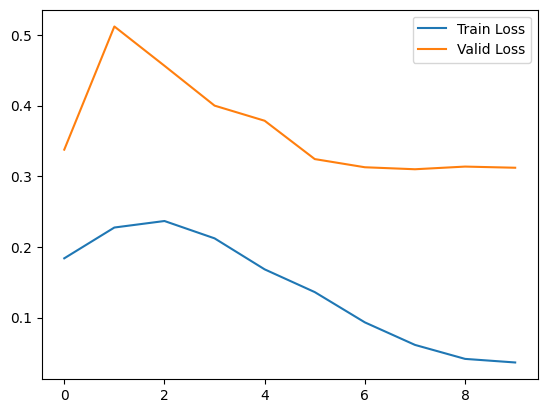

In [25]:
import matplotlib.pyplot as plt

values = learn.recorder.values

train_loss = [v[0] for v in values]
valid_loss = [v[1] for v in values]

plt.plot(train_loss, label="Train Loss")
plt.plot(valid_loss, label="Valid Loss")
plt.legend()
plt.show()